# Project: New Handwritten Digit Generating using Navie Bayes Algo

This project demonstrates generating new handwritten digit images using a Naive Bayes algorithm (specifically, Bernoulli Naive Bayes) trained on the MNIST dataset.
We are using Naive Bayes as a generative model to learn the probability of each pixel being black for each digit class (0–9), and then you can use these probabilities to generate new, synthetic digit images.

## Installing Packages

In [1]:
%pip install numpy keras matplotlib scikit-learn tensorflow

Note: you may need to restart the kernel to use updated packages.


## Importing Libraries

In [2]:
# example of training a gan on mnist
from numpy import expand_dims
from numpy import zeros
from numpy import ones
from numpy import vstack
from numpy.random import randn
from numpy.random import randint
from keras.datasets import mnist
from matplotlib import pyplot
import matplotlib.pyplot as plt

2025-06-12 14:16:31.815106: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-12 14:16:31.819824: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-12 14:16:31.829475: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749737791.844531    5988 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749737791.849075    5988 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1749737791.864773    5988 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

## Training Data

Load the MNIST dataset from Keras. Note: Since, the problem is to generate the new sample but not to predict the class label, we will not be using the test data.

In [3]:
(train_X, train_y), (test_X, test_y) = mnist.load_data()
print('X_train: ' + str(train_X.shape))
X_train: (60000, 28, 28) # training images

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
X_train: (60000, 28, 28)


## Flattening Images

To use Naive Bayes, we need each image as a flat vector of features (pixels). We reshape the 28x28 images into 1D arrays of length 784. Flatten each image so that rather than a 28x28 array, it is a 1x784 array.

In [4]:
train_X = train_X.reshape(train_X.shape[0], train_X.shape[1]*train_X.shape[2]) 
print('X_train: ' + str(train_X.shape))
print('X_train: ' + str(train_X[1].shape))
X_train: (60000, 784)
X_train: (784,)

X_train: (60000, 784)
X_train: (784,)


## Scaling Down

Divide each pixel value by 255 so that all values are between 0 and 1. At this point, your X array should have shape (num_examples, 784) and have values between 0 and 1.

In [5]:
train_X = train_X/255 # scale from [0,255] to [0,1]

## Training on labels

The Y array should be an array that contains the label (e.g. an image of a 6 will have label 6) and should have length = num_examples.

In [8]:
print(train_y[:10])  # Show the first 10 labels

[5 0 4 1 9 2 1 3 1 4]


## Training a Bernoulli Naive Bayes model

In [9]:
from sklearn.naive_bayes import BernoulliNB
clf = BernoulliNB()
model = clf.fit(train_X, train_y)

## Setting probability to black

Get the probabilities for each pixel to be black (i.e. the probability that that pixel will equal one for that class). Do this for every class.

In [11]:
# Get the probability of each pixel being black (value=1) for each class
from numpy import exp
pixel_black_probs = exp(model.feature_log_prob_)
print(pixel_black_probs.shape)  # Should be (10, 784) for 10 classes and 784 pixels

(10, 784)


## Generating and display a new digit image

> **Note: Limitations**  
> The generated images may not resemble real handwritten digits. This is because Naive Bayes assumes all pixels are independent, which is not true for images. For more realistic results, consider using models like GANs or VAEs.

## Results and Discussion

The generated digit above is created by sampling each pixel independently according to the learned probabilities for the chosen digit class. As expected, the image lacks the structure of real handwritten digits, highlighting the limitations of Naive Bayes as a generative model for images.

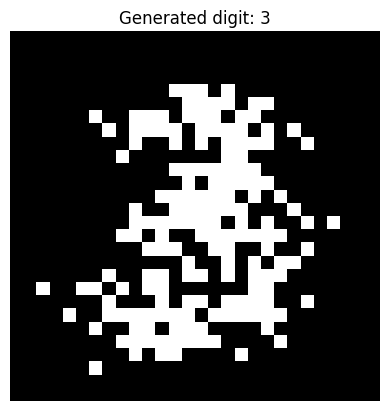

In [12]:
from numpy import random

digit_class = 3  # Choose the digit you want to generate
# Sample each pixel as 1 (black) with the learned probability, else 0 (white)
generated_digit = random.binomial(1, pixel_black_probs[digit_class]).reshape(28, 28)

plt.imshow(generated_digit, cmap='gray')
plt.title(f'Generated digit: {digit_class}')
plt.axis('off')
plt.show()

## References

- [MNIST Dataset](http://yann.lecun.com/exdb/mnist/)
- [Bernoulli Naive Bayes - scikit-learn docs](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.BernoulliNB.html)
- [Generative Adversarial Networks (GANs)](https://arxiv.org/abs/1406.2661)